# Análise Exploratória de Dados - Sample Superstore

## Objetivo do Projeto

Este projeto tem como objetivo realizar uma análise exploratória dos dados da base Sample Superstore utilizando Python, Pandas e Matplotlib. A análise busca identificar padrões de vendas, lucratividade, desempenho de categorias, regiões, estados, produtos e clientes, gerando insights que possam apoiar a tomada de decisões.

## Sobre a Base de Dados

A base utilizada neste projeto é a Sample Superstore, um conjunto de dados fictício amplamente utilizado para estudos de análise de dados. Ela contém informações sobre pedidos realizados entre 2014 e 2017, incluindo vendas, lucro, quantidade, categorias, clientes, estados e regiões.

## Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas que serão utilizadas durante toda a análise dos dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Carregamento da Base de Dados

In [5]:
df = pd.read_csv(
    "../dados/archive/Sample - Superstore.csv",
    encoding="latin1"
)

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Conhecendo a Base de Dados

Antes de iniciar as análises, é importante compreender a estrutura do conjunto de dados, verificando suas colunas, tipos de dados e informações gerais.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [10]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 9994
Colunas: 21


## Indicadores Gerais (KPIs)

Nesta etapa são apresentados os principais indicadores da base de dados, permitindo uma visão geral do desempenho das vendas antes de iniciar as análises detalhadas.

In [74]:
faturamento = df["Sales"].sum()
lucro = df["Profit"].sum()
quantidade = df["Quantity"].sum()
total_pedidos = df["Order ID"].nunique()
print(f"Faturamento Total: ${faturamento:,.2f}")
print(f"Lucro Total: ${lucro:,.2f}")
print(f"Quantidade de produtos vendidos: {quantidade}")
print(f"Total de pedidos: {total_pedidos}")

Faturamento Total: $2,297,200.86
Lucro Total: $286,397.02
Quantidade de produtos vendidos: 37873
Total de pedidos: 5009


### Análise

Os indicadores gerais oferecem uma visão inicial do desempenho da empresa. O faturamento representa o valor total das vendas realizadas, o lucro indica o retorno financeiro obtido, a quantidade corresponde ao total de produtos comercializados e o total de pedidos representa a quantidade de pedidos únicos registrados no período analisado. Esses indicadores servem como base para compreender o cenário geral antes das análises mais específicas.

## Análise por Categoria

Nesta análise é avaliado o desempenho das categorias de produtos em relação ao faturamento e ao lucro.

### Faturamento por Categoria

In [17]:
vendas_categoria = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
vendas_categoria

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

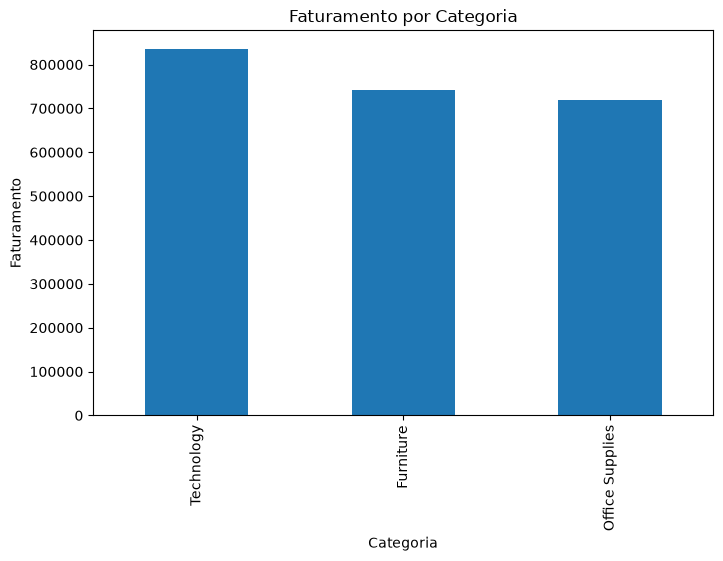

In [63]:
plt.figure(figsize=(8,5))

vendas_categoria.plot(kind="bar")

plt.title("Faturamento por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento")

plt.show()

### Análise

A categoria Technology apresentou o maior faturamento, seguida por Furniture e Office Supplies. Isso indica que os produtos de tecnologia tiveram maior participação nas vendas da empresa durante o período analisado.

### Lucro por Categoria

In [60]:
lucro_categoria = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
lucro_categoria

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

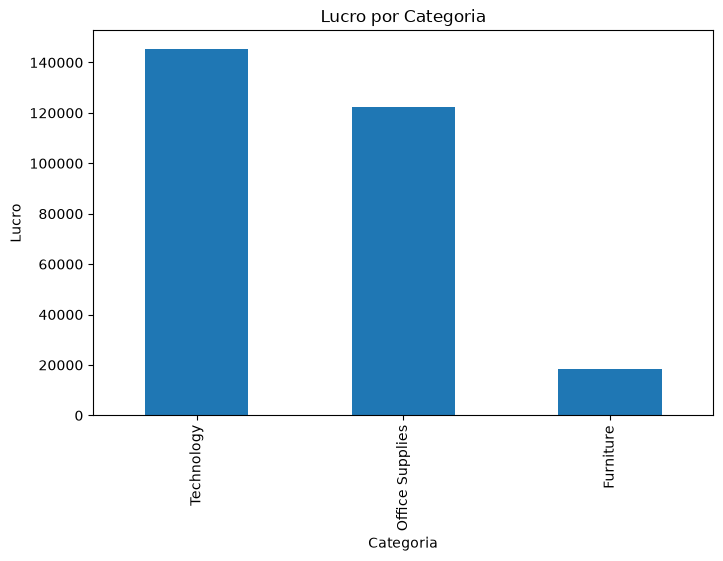

In [64]:
plt.figure(figsize=(8,5))

lucro_categoria.plot(kind="bar")

plt.title("Lucro por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Lucro")

plt.show()

### Análise

A categoria Technology também apresentou o maior lucro entre as categorias analisadas. Já a categoria Furniture apresentou um desempenho inferior, indicando uma menor rentabilidade em comparação com as demais.

## Análise por Região

Nesta seção é avaliado o faturamento obtido em cada região, permitindo identificar onde a empresa apresenta melhor desempenho em vendas.

### Faturamento por Região

In [19]:
vendas_regiao = (
    df.groupby("Region")["Sales"].sum().sort_values(ascending=False))
vendas_regiao

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

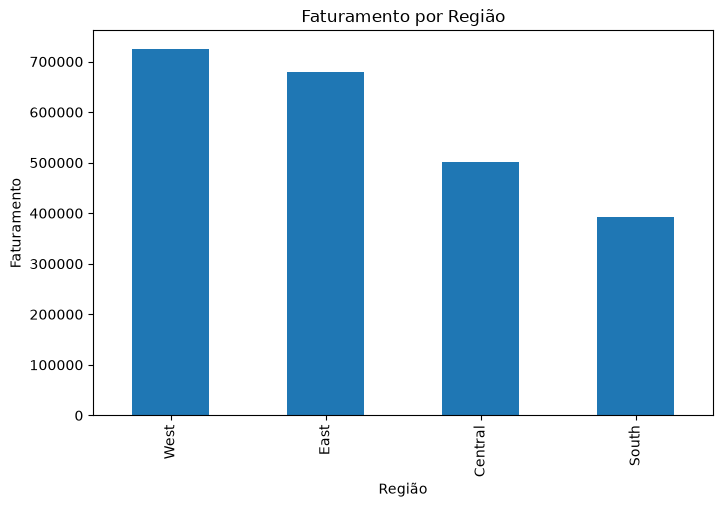

In [65]:
plt.figure(figsize=(8,5))

vendas_regiao.plot(kind="bar")

plt.title("Faturamento por Região")
plt.xlabel("Região")
plt.ylabel("Faturamento")

plt.show()

### Análise

A região West apresentou o maior faturamento entre todas as regiões analisadas, enquanto South registrou o menor resultado. Essa diferença demonstra que o desempenho das vendas varia significativamente entre as regiões.

## Análise por Estado

Nesta etapa é analisado o desempenho dos estados em relação ao faturamento e ao lucro, permitindo identificar quais localidades mais contribuíram para os resultados da empresa.

### Faturamento por Estado

In [27]:
vendas_estado = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top10_estados = vendas_estado.head(10)

top10_estados

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

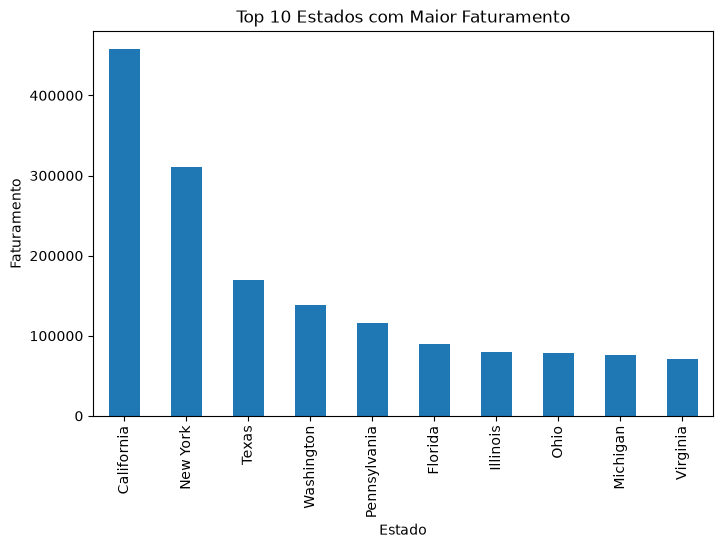

In [66]:
plt.figure(figsize=(8,5))

top10_estados.plot(kind="bar")

plt.title("Top 10 Estados com Maior Faturamento")
plt.xlabel("Estado")
plt.ylabel("Faturamento")

plt.show()

### Análise

A análise do faturamento por estado mostrou que **California** foi o estado que mais contribuiu para a receita da empresa. Os demais estados apresentaram faturamentos menores, evidenciando diferenças significativas no desempenho das vendas entre as localidades.

### Lucro por Estado

In [29]:
lucro_estado = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

top10_lucro = lucro_estado.head(10)

top10_lucro

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

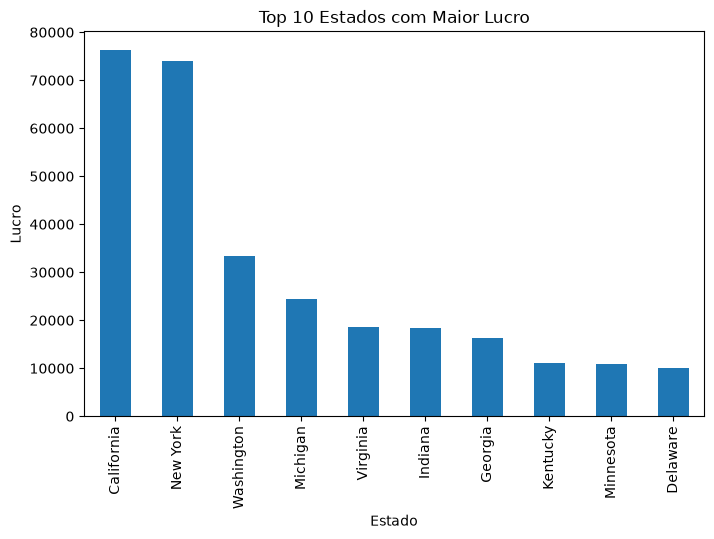

In [67]:
plt.figure(figsize=(8,5))

top10_lucro.plot(kind="bar")

plt.title("Top 10 Estados com Maior Lucro")
plt.xlabel("Estado")
plt.ylabel("Lucro")

plt.show()

### Análise

A análise do lucro por estado revelou que California também apresentou o maior lucro, indicando que, além de gerar elevado faturamento, suas vendas foram mais rentáveis. Isso demonstra a importância desse estado para os resultados financeiros da empresa.

## Evolução das Vendas ao Longo do Tempo

Nesta etapa é analisado o comportamento do faturamento ao longo dos anos, permitindo identificar tendências de crescimento ou redução nas vendas.

In [31]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [33]:
df["Ano"] = df["Order Date"].dt.year
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ano
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015


### Evolução do Faturamento por Ano

In [34]:
vendas_ano = (
    df.groupby("Ano")["Sales"]
    .sum()
)

vendas_ano

Ano
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

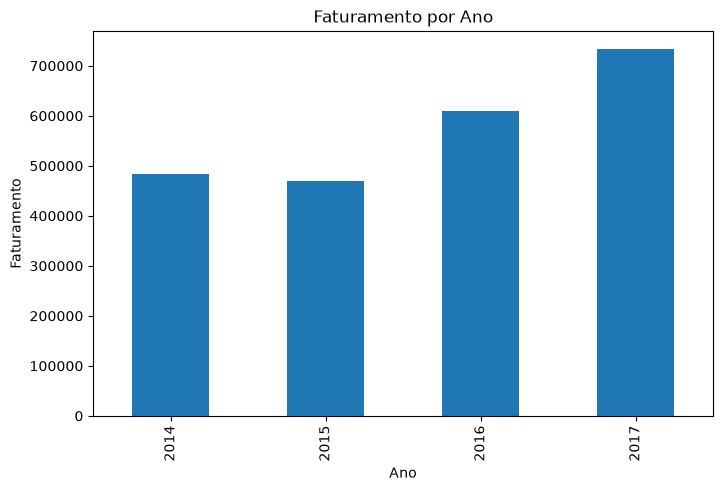

In [68]:
plt.figure(figsize=(8,5))

vendas_ano.plot(kind="bar")

plt.title("Faturamento por Ano")
plt.xlabel("Ano")
plt.ylabel("Faturamento")

plt.show()


### Análise

O faturamento apresentou uma tendência de crescimento ao longo do período analisado. Após uma pequena redução em 2015, observou-se um aumento significativo em 2016 e um crescimento ainda maior em 2017, que registrou o melhor desempenho entre todos os anos.

## Análise dos Produtos

Nesta etapa são analisados os produtos sob diferentes perspectivas, considerando quantidade vendida, faturamento e lucratividade.

### Produtos Mais Vendidos

In [36]:
produtos_qtd = (
    df.groupby("Product Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

produtos_qtd.head(10)

Product Name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: Quantity, dtype: int64

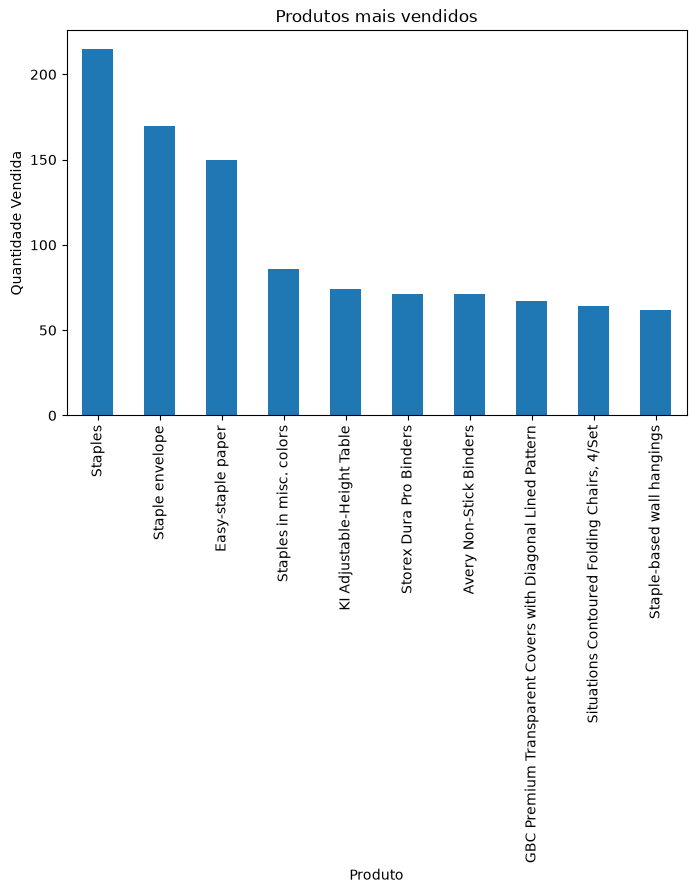

In [69]:
top10_produtos = produtos_qtd.head(10)

plt.figure(figsize=(8,5))

top10_produtos.plot(kind="bar")

plt.title("Produtos mais vendidos")
plt.xlabel("Produto")
plt.ylabel("Quantidade Vendida")

plt.show()

### Análise

Os produtos mais vendidos em quantidade foram principalmente itens de escritório, como grampos, envelopes e papel. Entretanto, vender uma grande quantidade de unidades não significa, necessariamente, gerar maior faturamento para a empresa.

### Produtos com Maior Faturamento

Nesta análise são identificados os produtos que mais contribuíram para o faturamento da empresa.

In [39]:
produtos_faturamento = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

produtos_faturamento.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

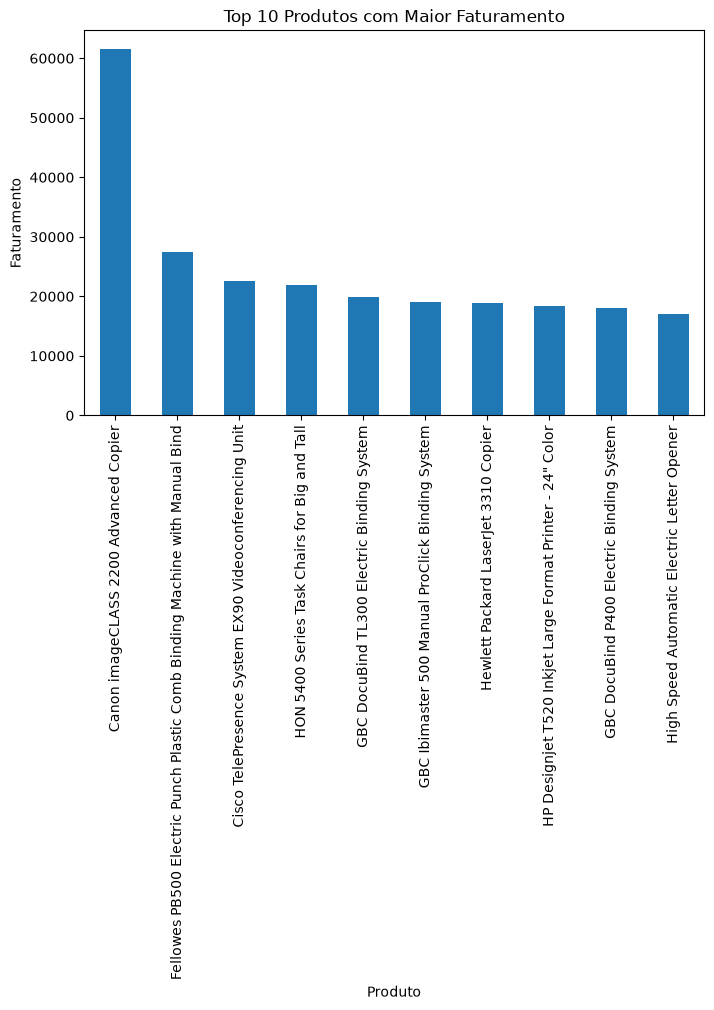

In [70]:
top10_faturamento = produtos_faturamento.head(10)

plt.figure(figsize=(8,5))

top10_faturamento.plot(kind="bar")

plt.title("Top 10 Produtos com Maior Faturamento")
plt.xlabel("Produto")
plt.ylabel("Faturamento")

plt.show()

### Análise

Os produtos com maior faturamento foram equipamentos de alto valor agregado, como copiadoras e sistemas de videoconferência. Embora esses produtos não estejam entre os mais vendidos em quantidade, eles geram uma parcela significativa da receita da empresa devido ao seu alto valor de venda.

### Produtos com Maior Prejuízo

Nesta etapa são identificados os produtos que apresentaram os maiores prejuízos, auxiliando na identificação de possíveis oportunidades de melhoria na estratégia comercial.

In [48]:
produtos_prejuizo = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
)

produtos_prejuizo.head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

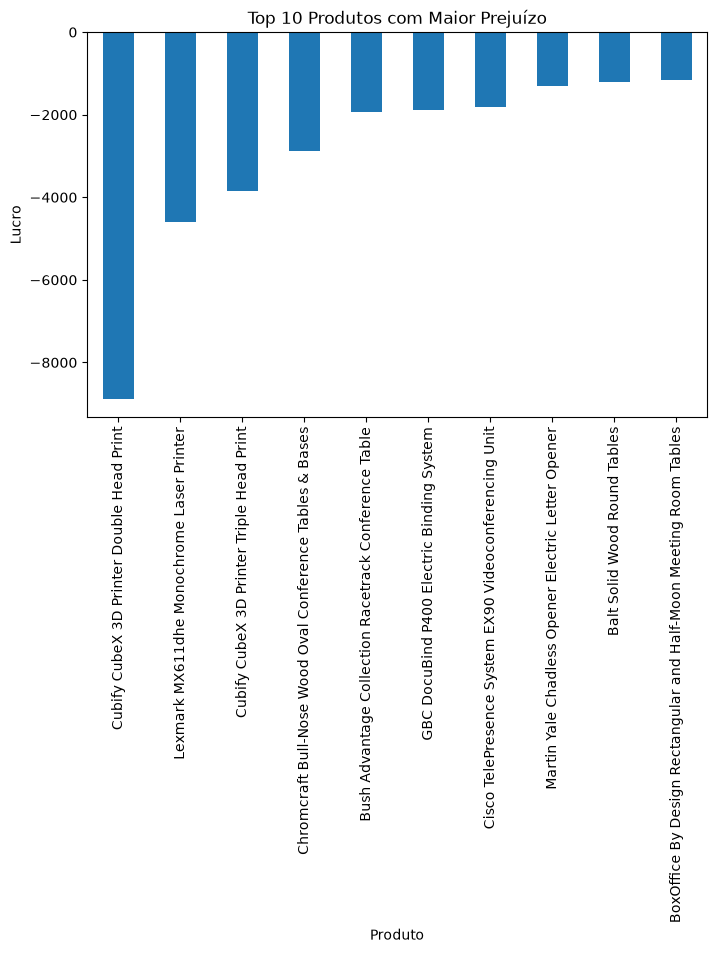

In [71]:
top10_prejuizo = produtos_prejuizo.head(10)

plt.figure(figsize=(8,5))

top10_prejuizo.plot(kind="bar")

plt.title("Top 10 Produtos com Maior Prejuízo")
plt.xlabel("Produto")
plt.ylabel("Lucro")

plt.show()

### Análise

A análise identificou produtos que apresentaram lucro negativo, indicando prejuízo para a empresa. Esses resultados sugerem a necessidade de avaliar fatores como custos, descontos aplicados ou estratégias de precificação, buscando reduzir impactos negativos na rentabilidade.

## Análise dos Clientes

Nesta seção são analisados os clientes que mais contribuíram para o faturamento da empresa.

### Clientes com Maior Faturamento

In [53]:
clientes = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

clientes.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

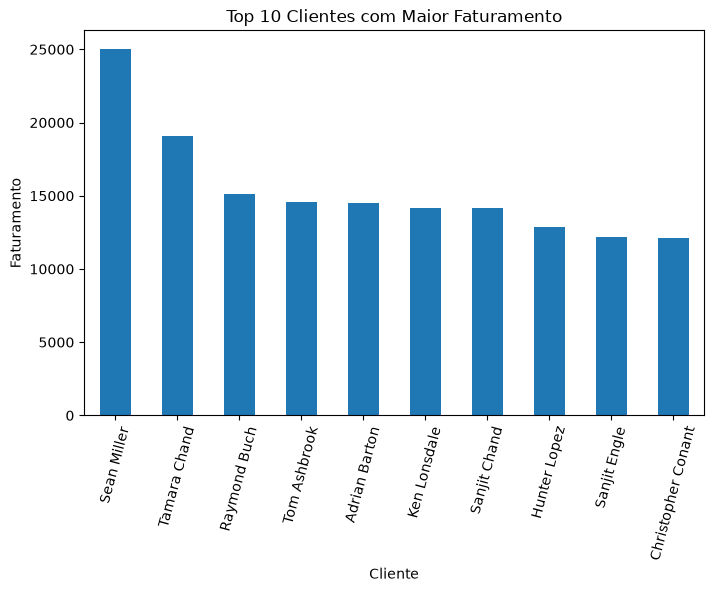

In [72]:
top10_clientes = clientes.head(10)

plt.figure(figsize=(8,5))

top10_clientes.plot(kind="bar")

plt.title("Top 10 Clientes com Maior Faturamento")
plt.xlabel("Cliente")
plt.ylabel("Faturamento")

plt.xticks(rotation=75)

plt.show()

### Análise

A análise permitiu identificar os clientes que mais contribuíram para o faturamento da empresa. Conhecer esses clientes é importante para apoiar estratégias de fidelização, fortalecimento do relacionamento e desenvolvimento de ações comerciais direcionadas.

## Análise por Segmento

Nesta etapa é analisado o faturamento por segmento de clientes, permitindo identificar qual perfil de cliente gera maior receita para a empresa.

In [57]:
vendas_segmento = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

vendas_segmento

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

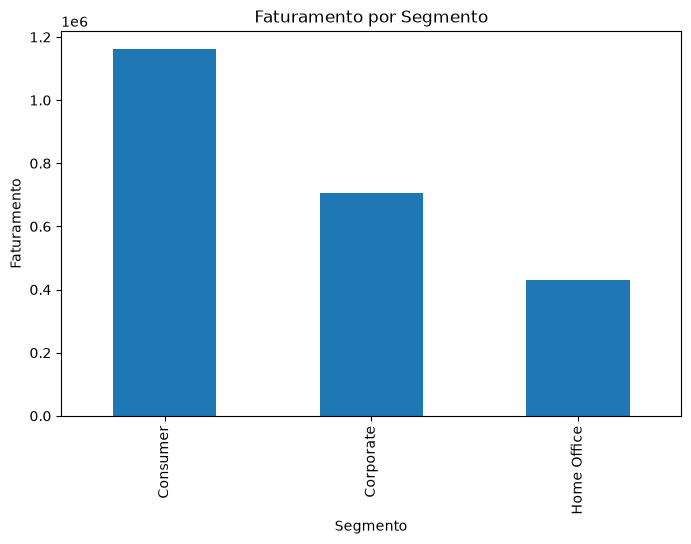

In [73]:
plt.figure(figsize=(8,5))

vendas_segmento.plot(kind="bar")

plt.title("Faturamento por Segmento")
plt.xlabel("Segmento")
plt.ylabel("Faturamento")

plt.show()

### Análise

Entre os segmentos analisados, **Consumer** apresentou o maior faturamento, demonstrando ser o principal responsável pela receita da empresa. Os segmentos **Corporate** e **Home Office** também contribuíram para as vendas, porém em menor escala.

# Conclusões

A análise exploratória da base **Sample Superstore** permitiu identificar padrões importantes relacionados às vendas, ao lucro e ao desempenho da empresa.

### Principais insights

- A categoria **Technology** apresentou o maior faturamento e também o maior lucro entre as categorias analisadas.
- A região **West** foi a que obteve o maior faturamento, enquanto **South** apresentou o menor desempenho.
- O estado da **California** destacou-se tanto em faturamento quanto em lucro, demonstrando sua importância para os resultados da empresa.
- O faturamento apresentou crescimento ao longo dos anos, com **2017** registrando o melhor desempenho.
- Os produtos mais vendidos em quantidade não foram, necessariamente, os que geraram maior faturamento.
- Alguns produtos apresentaram prejuízo, indicando oportunidades para revisão de estratégias de precificação e custos.
- Foi possível identificar os clientes e segmentos que mais contribuíram para a receita da empresa.

De forma geral, a análise da base Sample Superstore permitiu identificar diferenças importantes no desempenho da empresa. A categoria Technology apresentou o maior faturamento e lucro, enquanto a região West e o estado da California se destacaram nos resultados. Também foi possível observar o crescimento do faturamento ao longo dos anos e identificar que produtos com maior volume de vendas não são necessariamente os que geram maior receita.

Além disso, a análise revelou produtos com prejuízo e permitiu identificar clientes e segmentos com maior participação no faturamento. Esses resultados reforçam a importância de analisar não apenas o volume de vendas, mas também a lucratividade, os produtos e os diferentes perfis e regiões, contribuindo para decisões mais direcionadas sobre vendas, custos e estratégias comerciais.